# Custom BKT — population-level analysis

This notebook uses BKT parameters as **population-level descriptors** of each skill (difficulty, learnability, noise). Individual per-student predictions are not generated because most student–skill sequences in KT1 are too short (median = 2 attempts) to produce reliable estimates.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import defaultdict
from joblib import Parallel, delayed
from sklearn.metrics import roc_auc_score, mean_squared_error

plt.rcParams.update({
    'figure.dpi': 110, 'savefig.dpi': 110,
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.alpha': 0.3,
})

## 1. Load & pre-process

In [6]:
df = pd.read_csv("5kfiles_kt1.csv")
df = df.drop(columns=["Unnamed: 0"])
df['question_id'] = df['question_id'].str.lstrip('q').astype(int)

In [7]:
df_question_content = pd.read_csv("contents\\questions.csv")

df_question_content['tag_list'] = df_question_content['tags'].str.split(';')
df_question_content['question_id_int'] = (
    df_question_content['question_id'].str.lstrip('q').astype(int)
)

questions_exploded = df_question_content.explode('tag_list')
question_skills = (
    questions_exploded[['question_id_int', 'tag_list', 'correct_answer']]
    .drop_duplicates()
    .rename(columns={'question_id_int': 'question_id', 'tag_list': 'skill_name'})
)

In [8]:
df_merged = pd.merge(df, question_skills, on='question_id', how='left')
df_merged['correct'] = (df_merged['user_answer'] == df_merged['correct_answer']).astype(int)

df_merged = df_merged.sort_values(['user_id', 'timestamp'])
df_merged['order_id'] = df_merged.groupby('user_id').cumcount() + 1

df_bkt = df_merged[['user_id', 'skill_name', 'correct', 'order_id']]
df_bkt.head()

,user_id,skill_name,correct,order_id
0,1,74,0,1
1,1,71,1,2
2,1,103,1,3
3,1,83,0,4
4,1,90,0,5


## 2. Custom BKT — optimised (Baum-Welch EM)

### What changed and why

| Original | Optimised | Speedup |
|---|---|---|
| Loop over every student sequence one-by-one | **Batch-vectorise** across all sequences of the same length simultaneously | ~29× per skill |
| Sequential skill fitting | **Parallel** skill fitting via `joblib` | ×n_cores |
| Per-group Python loop in `predict_bkt` | Vectorised forward pass over all users per skill | minor |

**How batch vectorisation works:**  
Sequences are grouped by length. Within each length-group the forward pass, backward pass, γ and ξ accumulators are all computed as 3-D NumPy operations `(time, students, states)` — replacing the innermost Python `for seq in seqs` loop with a single set of array ops.  The EM maths is identical; only the execution path changes.

In [ ]:
# ─── forward_pass ─────────────────────────────────────────────────────────────
# (unchanged — still used for prediction one sequence at a time)
def forward_pass(sequence, prior, learn, guess, slip):
    """Filtered P(correct) at each step — used for predictions only."""
    p_l = prior
    predictions = []
    for correct in sequence:
        p_correct = p_l * (1 - slip) + (1 - p_l) * guess
        predictions.append(p_correct)
        if correct == 1:
            num = p_l * (1 - slip)
            den = num + (1 - p_l) * guess
        else:
            num = p_l * slip
            den = num + (1 - p_l) * (1 - guess)
        p_l_given_obs = num / den if den > 0 else p_l
        p_l = p_l_given_obs + (1 - p_l_given_obs) * learn
    return predictions


# ─── fit_skill ────────────────────────────────────────────────────────────────
def fit_skill(sequences, n_iter=100, tol=1e-5,
              init_prior=0.3, init_learn=0.1,
              init_guess=0.2, init_slip=0.1):
    """Fit one skill via Baum-Welch EM — batch-vectorised across sequences.

    Sequences are grouped by length so that all students with the same
    number of attempts are processed together as a (time × students × states)
    array, eliminating the inner Python loop over individual sequences.
    """
    by_length = defaultdict(list)
    for s in sequences:
        if len(s) > 0:
            by_length[len(s)].append(s)
    # Each batch: numpy array of shape (N_students, length)
    batches = [(L, np.array(seqs, dtype=np.int8))
               for L, seqs in by_length.items()]
    if not batches:
        return {'prior': init_prior, 'learn': init_learn,
                'guess': init_guess, 'slip': init_slip,
                'n_sequences': 0, 'n_obs': 0,
                'log_likelihood': float('nan'), 'iterations': 0}

    prior, learn, guess, slip = init_prior, init_learn, init_guess, init_slip
    n_sequences = sum(b.shape[0] for _, b in batches)
    n_obs_total  = sum(L * b.shape[0] for L, b in batches)
    prev_ll = -np.inf

    for it in range(n_iter):
        sum_prior_post  = 0.0
        sum_xi_01       = 0.0
        sum_gamma0_trans = 0.0
        sum_correct_nl  = 0.0
        sum_total_nl    = 0.0
        sum_wrong_l     = 0.0
        sum_total_l     = 0.0
        total_ll        = 0.0
        n_seq           = 0
        A00, A01        = 1 - learn, learn

        for L, batch in batches:          # batch: (N, L)
            N   = batch.shape[0]
            obs = batch.T.astype(np.float64)  # (L, N) — easier for time-first indexing

            # Emissions b[t, student, state]  shape (L, N, 2)
            b = np.empty((L, N, 2))
            b[:, :, 0] = np.where(obs == 1, guess,    1 - guess)
            b[:, :, 1] = np.where(obs == 1, 1 - slip, slip)

            # ── Forward pass (scaled Rabiner) ──────────────────────────────
            alpha = np.empty((L, N, 2))
            sc    = np.empty((L, N))

            alpha[0, :, 0] = (1 - prior) * b[0, :, 0]
            alpha[0, :, 1] =      prior  * b[0, :, 1]
            sc[0] = alpha[0].sum(axis=1)
            ok = sc[0] > 0
            alpha[0, ok] /= sc[0, ok, None]

            for t in range(1, L):
                alpha[t, :, 0] = b[t, :, 0] * alpha[t-1, :, 0] * A00
                alpha[t, :, 1] = b[t, :, 1] * (alpha[t-1, :, 0] * A01
                                                + alpha[t-1, :, 1])
                sc[t] = alpha[t].sum(axis=1)
                ok = sc[t] > 0
                alpha[t, ok] /= sc[t, ok, None]

            total_ll += np.sum(np.log(sc + 1e-300))

            # ── Backward pass (same scaling) ───────────────────────────────
            beta = np.empty((L, N, 2))
            ok_last = sc[L-1] > 0
            beta[L-1] = 1.0
            beta[L-1, ok_last] /= sc[L-1, ok_last, None]

            for t in range(L - 2, -1, -1):
                beta[t, :, 0] = (A00 * b[t+1, :, 0] * beta[t+1, :, 0]
                                 + A01 * b[t+1, :, 1] * beta[t+1, :, 1])
                beta[t, :, 1] = b[t+1, :, 1] * beta[t+1, :, 1]
                ok = sc[t] > 0
                beta[t, ok] /= sc[t, ok, None]

            # ── State posteriors γ  shape (L, N, 2) ───────────────────────
            gamma = alpha * beta
            gs    = gamma.sum(axis=2, keepdims=True)
            gamma = np.where(gs > 0, gamma / np.where(gs > 0, gs, 1.0), gamma)

            # ── Transition posteriors ξ (no-forgetting: ξ[1→0] = 0) ──────
            if L > 1:
                xi00 = alpha[:-1,:,0] * A00 * b[1:,:,0] * beta[1:,:,0]
                xi01 = alpha[:-1,:,0] * A01 * b[1:,:,1] * beta[1:,:,1]
                xi11 = alpha[:-1,:,1]        * b[1:,:,1] * beta[1:,:,1]
                z    = xi00 + xi01 + xi11
                ok   = z > 0
                xi01n = np.where(ok, xi01 / np.where(ok, z, 1.0), 0.0)
                xi00n = np.where(ok, xi00 / np.where(ok, z, 1.0), 0.0)
                sum_xi_01        += xi01n.sum()
                sum_gamma0_trans += (xi00n + xi01n).sum()

            sum_prior_post += gamma[0, :, 1].sum()
            n_seq          += N
            sum_total_nl   += gamma[:, :, 0].sum()
            sum_total_l    += gamma[:, :, 1].sum()
            sum_correct_nl += gamma[:, :, 0][obs == 1].sum()
            sum_wrong_l    += gamma[:, :, 1][obs == 0].sum()

        # ── M-step ────────────────────────────────────────────────────────
        prior = float(np.clip(sum_prior_post  / max(n_seq, 1),              0.01,  0.99))
        learn = float(np.clip(sum_xi_01       / max(sum_gamma0_trans, 1e-12), 0.001, 0.99))
        guess = float(np.clip(sum_correct_nl  / max(sum_total_nl, 1e-12),   0.001, 0.4))
        slip  = float(np.clip(sum_wrong_l     / max(sum_total_l,  1e-12),   0.001, 0.4))

        if abs(total_ll - prev_ll) < tol:
            break
        prev_ll = total_ll

    return {'prior': prior, 'learn': learn, 'guess': guess, 'slip': slip,
            'n_sequences': n_sequences, 'n_obs': n_obs_total,
            'log_likelihood': total_ll, 'iterations': it + 1}


# ─── fit_bkt ──────────────────────────────────────────────────────────────────
def fit_bkt(df, n_iter=100, min_attempts_per_student=2, n_jobs=-1):
    """Fit BKT for all skills in parallel (n_jobs=-1 = all cores).

    Uses thread-based parallelism — NumPy releases the GIL during heavy
    array computation, so threads actually run concurrently here.
    """
    def _fit_one(skill):
        skill_df = df[df['skill_name'] == skill].sort_values(['user_id', 'order_id'])
        sequences = [
            group['correct'].tolist()
            for _, group in skill_df.groupby('user_id')
            if len(group) >= min_attempts_per_student
        ]
        if not sequences:
            return skill, None
        return skill, fit_skill(sequences, n_iter=n_iter)

    skills  = df['skill_name'].unique()
    results = Parallel(n_jobs=n_jobs, prefer='threads')(
        delayed(_fit_one)(sk) for sk in skills
    )
    return {sk: p for sk, p in results if p is not None}



## 3. Fit model

In [ ]:
import time

print("Fitting BKT for", df_bkt['skill_name'].nunique(), "skills...")
t0 = time.perf_counter()
bkt_params = fit_bkt(df_bkt, n_iter=100, min_attempts_per_student=3, n_jobs=-1)
elapsed = time.perf_counter() - t0
print(f"Done — {len(bkt_params)} skills fitted in {elapsed:.1f}s")

# Build params_df with reliability flags
MIN_OBS = 50  # minimum observations for trustworthy parameters

params_df = pd.DataFrame(bkt_params).T.round(4)
params_df.index.name = 'skill'

params_df['reliable'] = (
    (params_df['n_obs']  >= MIN_OBS) &
    (params_df['guess']  <  0.39)   &
    (params_df['slip']   <  0.35)   &
    (params_df['learn']  >= 0.01)   &
    (params_df['prior']  <= 0.95)
)
params_df['flag_guess_ceiling'] = params_df['guess'] >= 0.39
params_df['flag_low_learn']     = params_df['learn'] < 0.01
params_df['flag_high_prior']    = params_df['prior'] > 0.90
params_df['flag_sparse']        = params_df['n_obs'] < MIN_OBS

print(f"\nReliability summary ({len(params_df)} skills total):")
print(f"  Reliable:             {params_df['reliable'].sum()}")
print(f"  Flagged — guess cap:  {params_df['flag_guess_ceiling'].sum()}")
print(f"  Flagged — low learn:  {params_df['flag_low_learn'].sum()}")
print(f"  Flagged — high prior: {params_df['flag_high_prior'].sum()}")
print(f"  Flagged — sparse:     {params_df['flag_sparse'].sum()}")

params_df.head(10)


In [ ]:
# Save parameters (reliable flag included)
params_df.to_csv("bkt_params.csv")
print("Saved bkt_params.csv")


## 5. Export student sequences for prediction page

In [9]:
# ─── extract_real_student_sequence ────────────────────────────────────────
def extract_real_student_sequence(df, user_id):
    """Extract a real student's interaction sequence as CSV.
    
    Args:
        df: dataframe with columns ['user_id', 'skill_name', 'correct', 'order_id']
        user_id: the student ID to extract
    
    Returns:
        pandas DataFrame with columns ['skill', 'correct']
    """
    student_data = df[df['user_id'] == user_id].sort_values('order_id')
    if len(student_data) == 0:
        return pd.DataFrame(columns=['skill', 'correct'])
    
    return pd.DataFrame({
        'skill': student_data['skill_name'].astype(str),
        'correct': student_data['correct'].astype(int)
    }).reset_index(drop=True)


# ─── generate_synthetic_sequence ───────────────────────────────────────────
def generate_synthetic_sequence(params_df, n_attempts=15, skill_focus=None, noise=0.0):
    """Generate a synthetic student sequence using BKT parameters.
    
    Simulates a student learning over time, with probability of success
    increasing as knowledge accumulates.
    
    Args:
        params_df: dataframe of BKT parameters (from fit_bkt)
        n_attempts: number of attempts to generate
        skill_focus: if provided, use this skill 70% of the time
        noise: random noise to add to selection (0-1)
    
    Returns:
        pandas DataFrame with columns ['skill', 'correct']
    """
    skills = params_df.index.tolist()
    if skill_focus is not None and skill_focus not in skills:
        skill_focus = None
    
    sequence = []
    p_learned = 0.0
    
    for i in range(n_attempts):
        # Select skill: focus on one skill, or random
        if skill_focus and np.random.random() < 0.7:
            skill = skill_focus
        else:
            skill = np.random.choice(skills)
        
        # Get BKT parameters
        params = params_df.loc[skill]
        prior = params['prior']
        learn = params['learn']
        guess = params['guess']
        slip = params['slip']
        
        # Probability of correct answer given current knowledge
        p_correct = p_learned * (1 - slip) + (1 - p_learned) * guess
        
        # Generate outcome
        correct = 1 if np.random.random() < p_correct else 0
        
        # Update knowledge state
        if correct == 1:
            numerator = p_learned * (1 - slip)
        else:
            numerator = p_learned * slip
        denominator = p_learned * (1 - slip) + (1 - p_learned) * guess
        p_learned_given_obs = numerator / denominator if denominator > 0 else p_learned
        p_learned = p_learned_given_obs + (1 - p_learned_given_obs) * learn
        
        sequence.append({'skill': str(skill), 'correct': int(correct)})
    
    return pd.DataFrame(sequence)


# ─── export_student_sequences ──────────────────────────────────────────────
def export_student_sequences(df, output_dir=".", min_attempts=3, max_students=10):
    """Export multiple real student sequences as individual CSV files.
    
    Args:
        df: dataframe with columns ['user_id', 'skill_name', 'correct', 'order_id']
        output_dir: directory to save CSV files
        min_attempts: minimum attempts to include a student
        max_students: maximum number of students to export
    
    Returns:
        list of filenames saved
    """
    import os
    os.makedirs(output_dir, exist_ok=True)
    
    # Find students with enough attempts
    student_counts = df.groupby('user_id').size()
    eligible_students = student_counts[student_counts >= min_attempts].index.tolist()
    eligible_students = eligible_students[:max_students]
    
    filenames = []
    for user_id in eligible_students:
        seq = extract_real_student_sequence(df, user_id)
        filename = f"student_{user_id}_sequence.csv"
        filepath = os.path.join(output_dir, filename)
        seq.to_csv(filepath, index=False)
        filenames.append(filename)
    
    return filenames


# ─── create_sample_dataset ─────────────────────────────────────────────────
def create_sample_dataset(params_df, n_samples=20, n_attempts_range=(5, 20)):
    """Create a CSV file with multiple synthetic student sequences.
    
    Generates a combined CSV where each row is an attempt, and sequences
    are separated by student_id.
    
    Args:
        params_df: dataframe of BKT parameters
        n_samples: number of synthetic students to generate
        n_attempts_range: tuple (min, max) attempts per student
    
    Returns:
        pandas DataFrame with columns ['student_id', 'skill', 'correct']
    """
    all_sequences = []
    
    for student_id in range(1, n_samples + 1):
        n_attempts = np.random.randint(n_attempts_range[0], n_attempts_range[1] + 1)
        skill_focus = np.random.choice(params_df.index)
        
        seq = generate_synthetic_sequence(params_df, n_attempts, skill_focus)
        seq['student_id'] = student_id
        all_sequences.append(seq)
    
    return pd.concat(all_sequences, ignore_index=True)[['student_id', 'skill', 'correct']]

### Example 1: Extract real student sequence

In [18]:
# Extract a real student's sequence
student_id = df_bkt['user_id'].unique()[0]  # Get first student
real_sequence = extract_real_student_sequence(df_bkt, student_id)
print(f"Real student {student_id} sequence:")
print(real_sequence)
print(f"\n✓ Save to CSV for prediction page:")
real_sequence.to_csv("example_student_sequence.csv", index=False)
print("Saved example_student_sequence.csv")

Real student 1 sequence:
     skill  correct
0       74        0
1       71        1
2      103        1
3       83        0
4       90        0
...    ...      ...
2827    55        1
2828   183        1
2829    59        1
2830    56        1
2831   183        1

[2832 rows x 2 columns]

✓ Save to CSV for prediction page:
Saved example_student_sequence.csv


### Example 2: Generate synthetic student sequence

In [19]:
# Generate a synthetic student sequence using BKT parameters
synthetic_sequence = generate_synthetic_sequence(
    params_df, 
    n_attempts=12, 
    skill_focus=params_df.index[0],  # Focus on first skill
    noise=0.0
)
print("Generated synthetic student sequence:")
print(synthetic_sequence)
print(f"\n✓ Save to CSV for prediction page:")
synthetic_sequence.to_csv("synthetic_student_sequence.csv", index=False)
print("Saved synthetic_student_sequence.csv")

NameError: name 'params_df' is not defined

### Example 3: Create dataset with multiple synthetic students

In [20]:
# Create a dataset with 20 synthetic students
sample_dataset = create_sample_dataset(params_df, n_samples=20, n_attempts_range=(5, 15))
print(f"Created dataset with {sample_dataset['student_id'].nunique()} students")
print(f"Total attempts: {len(sample_dataset)}")
print("\nFirst few rows:")
print(sample_dataset.head(15))

# Save full dataset for dashboard
sample_dataset.to_csv("synthetic_student_dataset.csv", index=False)
print("\n✓ Saved synthetic_student_dataset.csv")

# Save to dashboard data folder for use in prediction page
import os
dashboard_path = "../S3C2-studentgrades/dashboard/data/synthetic_student_dataset.csv"
os.makedirs(os.path.dirname(dashboard_path), exist_ok=True)
sample_dataset.to_csv(dashboard_path, index=False)
print(f"✓ Also saved to {dashboard_path}")

NameError: name 'params_df' is not defined

### Example 4: Export real student sequences as separate files

In [21]:
# Export real student sequences from the dataset
filenames = export_student_sequences(
    df_bkt, 
    output_dir="real_student_sequences", 
    min_attempts=3, 
    max_students=5
)

print(f"✓ Exported {len(filenames)} real student sequences:")
for fname in filenames:
    print(f"  - {fname}")

# Optionally, load and display one
if filenames:
    first_sequence = pd.read_csv(f"real_student_sequences/{filenames[0]}")
    print(f"\nExample: {filenames[0]}")
    print(first_sequence)

✓ Exported 5 real student sequences:
  - student_1_sequence.csv
  - student_10_sequence.csv
  - student_100_sequence.csv
  - student_101_sequence.csv
  - student_102_sequence.csv

Example: student_1_sequence.csv
      skill  correct
0        74        0
1        71        1
2       103        1
3        83        0
4        90        0
...     ...      ...
2827     55        1
2828    183        1
2829     59        1
2830     56        1
2831    183        1

[2832 rows x 2 columns]


## 4. Population-level skill characterisation

In [10]:
# Skill characterisation (reliable skills only)
reliable = params_df[params_df['reliable']].copy()
print(f"Characterising {len(reliable)} reliable skills\n")

print("=== Hardest skills  (lowest prior knowledge) ===")
print(reliable.nsmallest(10, 'prior')[['prior','learn','guess','slip','n_obs']].to_string())

print("\n=== Most learnable skills  (highest learn rate) ===")
print(reliable.nlargest(10, 'learn')[['prior','learn','guess','slip','n_obs']].to_string())

print("\n=== Noisiest skills  (highest guess + slip) ===")
reliable['noise'] = reliable['guess'] + reliable['slip']
print(reliable.nlargest(10, 'noise')[['prior','learn','guess','slip','noise','n_obs']].to_string())


NameError: name 'params_df' is not defined

In [ ]:
# Population mastery rates
# For every reliable skill, simulate the BKT forward pass for each student
# and record: did they reach P(L) >= 0.95, and after how many attempts?

MASTERY_THRESHOLD = 0.95

def skill_mastery_stats(skill, df_bkt, params, threshold=MASTERY_THRESHOLD):
    p = params[skill]
    rows = []
    for _, grp in df_bkt[df_bkt['skill_name'] == skill].groupby('user_id'):
        obs = grp.sort_values('order_id')['correct'].tolist()
        p_l = p['prior']
        mastered, atm = False, None
        for i, c in enumerate(obs):
            num = p_l * (1 - p['slip']) if c == 1 else p_l * p['slip']
            den = (num + (1 - p_l) * p['guess']) if c == 1 else (num + (1 - p_l) * (1 - p['guess']))
            p_l = (num / den if den > 0 else p_l)
            p_l = p_l + (1 - p_l) * p['learn']
            if p_l >= threshold and not mastered:
                mastered, atm = True, i + 1
        rows.append({'mastered': mastered, 'attempts_to_mastery': atm, 'n_attempts': len(obs)})
    df_r = pd.DataFrame(rows)
    return {
        'mastery_rate': df_r['mastered'].mean(),
        'median_atm':   df_r.loc[df_r['mastered'], 'attempts_to_mastery'].median(),
        'n_students':   len(df_r),
    }

mastery_rows = {}
for sk in reliable.index:
    mastery_rows[sk] = skill_mastery_stats(sk, df_bkt, bkt_params)

mastery_df = pd.DataFrame(mastery_rows).T
mastery_df = mastery_df.join(reliable[['prior', 'learn', 'n_obs']])
mastery_df = mastery_df.sort_values('mastery_rate', ascending=False)

print("Population mastery summary (reliable skills):")
print(mastery_df.round(3).to_string())


## 5. Visualisations

In [ ]:
# ── 1. Parameter distributions ──────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(11, 7))
for ax, col, color in zip(
    axes.flat,
    ['prior', 'learn', 'guess', 'slip'],
    ['#4C72B0', '#55A868', '#C44E52', '#8172B2'],
):
    ax.hist(params_df[col], bins=30, color=color, alpha=0.85, edgecolor='white')
    ax.axvline(params_df[col].mean(), color='black', linestyle='--', linewidth=1,
               label=f"mean={params_df[col].mean():.3f}")
    ax.set_title(f"{col}  (n={len(params_df)} skills)")
    ax.set_xlabel(col); ax.set_ylabel('number of skills')
    ax.legend(loc='upper right', frameon=False)
fig.suptitle("BKT parameter distributions across skills", y=1.02, fontsize=13)
fig.tight_layout(); plt.show()

In [ ]:
# Guess vs. slip — coloured by reliability
fig, ax = plt.subplots(figsize=(7, 6))
for label, mask, color, alpha in [
    ('Reliable',   params_df['reliable'],  '#4C72B0', 0.80),
    ('Unreliable', ~params_df['reliable'], '#aaaaaa', 0.35),
]:
    sub = params_df[mask]
    sizes = np.log1p(sub['n_obs']) * 8 if 'n_obs' in sub.columns else 40
    ax.scatter(sub['guess'], sub['slip'], s=sizes, alpha=alpha,
               c=color, edgecolor='white', linewidth=0.5, label=label)

xs = np.linspace(0, 0.5, 50)
ax.plot(xs, 1 - xs, '--', color='red',  alpha=0.5, label='guess + slip = 1')
ax.plot([0, 0.5], [0, 0.5], ':',  color='gray', alpha=0.5, label='guess = slip')
ax.set_xlabel('guess'); ax.set_ylabel('slip')
ax.set_xlim(0, 0.5);    ax.set_ylim(0, 0.5)
ax.set_title("Guess vs. slip per skill  (size ∝ log n_obs)")
ax.legend(frameon=False); plt.tight_layout(); plt.show()


In [ ]:
# ── 3. Empirical learning curves (top 6 skills) ────────────────────────────
top_skills = df_bkt['skill_name'].value_counts().head(6).index.tolist()
fig, ax = plt.subplots(figsize=(10, 6))
for skill in top_skills:
    sub = df_bkt[df_bkt['skill_name'] == skill].copy()
    sub['skill_attempt'] = sub.groupby('user_id').cumcount() + 1
    curve = sub.groupby('skill_attempt')['correct'].agg(['mean', 'count'])
    curve = curve[curve['count'] >= 20]
    ax.plot(curve.index[:30], curve['mean'].values[:30],
            marker='o', markersize=4, label=f"skill {skill} (n={len(sub):,})")
ax.set_xlabel('attempt number on this skill')
ax.set_ylabel('P(correct) — empirical mean')
ax.set_title("Empirical learning curves — 6 most-practised skills")
ax.legend(frameon=False, loc='lower right'); ax.set_ylim(0, 1.05)
plt.tight_layout(); plt.show()

In [ ]:
# Skill map: difficulty vs. learnability (reliable skills only)
fig, ax = plt.subplots(figsize=(9, 7))
sc = ax.scatter(
    reliable['prior'], reliable['learn'],
    s=np.log1p(reliable['n_obs']) * 10,
    c=reliable['learn'], cmap='YlGn',
    alpha=0.75, edgecolor='white', linewidth=0.5,
)
plt.colorbar(sc, ax=ax, label='learn rate')

for sk, row in reliable.nlargest(10, 'learn').iterrows():
    ax.annotate(str(sk), (row['prior'], row['learn']),
                fontsize=8, alpha=0.8,
                xytext=(4, 4), textcoords='offset points')

ax.axvline(0.5, linestyle='--', color='gray', alpha=0.4, label='prior = 0.5')
ax.axhline(0.1, linestyle=':', color='gray', alpha=0.4, label='learn = 0.1')
ax.set_xlabel('prior  (← harder   easier →)')
ax.set_ylabel('learn rate  (higher = faster learning)')
ax.set_title("Skill map — difficulty vs. learnability\n(reliable skills only, size ∝ log n_obs)")
ax.legend(frameon=False); plt.tight_layout(); plt.show()


In [ ]:
# Mastery rates for reliable skills
plot_df = mastery_df.dropna(subset=['mastery_rate']).sort_values('mastery_rate', ascending=True)

fig, ax = plt.subplots(figsize=(9, max(4, len(plot_df) * 0.35)))
colors = ['#55A868' if r >= 0.5 else '#C44E52' for r in plot_df['mastery_rate']]
ax.barh(plot_df.index.astype(str), plot_df['mastery_rate'], color=colors, alpha=0.85)
ax.axvline(0.5, linestyle='--', color='gray', alpha=0.5)
ax.set_xlabel('fraction of students reaching P(L) ≥ 0.95')
ax.set_title("Population mastery rate per reliable skill")
ax.set_xlim(0, 1)
plt.tight_layout(); plt.show()

# Attempts-to-mastery distribution
atm_vals = mastery_df['median_atm'].dropna()
if len(atm_vals):
    fig, ax = plt.subplots(figsize=(7, 4))
    ax.hist(atm_vals, bins=20, color='#4C72B0', alpha=0.85, edgecolor='white')
    ax.set_xlabel('median attempts to mastery (per skill)')
    ax.set_ylabel('number of skills')
    ax.set_title("Distribution of attempts-to-mastery across reliable skills")
    plt.tight_layout(); plt.show()


In [ ]:
# Optional diagnostics
attempts_per_student_skill = df_bkt.groupby(['user_id', 'skill_name']).size()
print(attempts_per_student_skill.describe())
print('Overall accuracy:', df_bkt['correct'].mean().round(3))


# 6. DKT implenmentation
First I do a quick diagnostic check, this makes sure that there is enough sequence length in a user to make sure DKT can actually ork. The code for thi ection i AI generated, all the tet and comment are hand ritten

In [11]:
total_per_learner = df_bkt.groupby('user_id')['correct'].count()
print(total_per_learner.describe())
print(f"Learners with < 20 total interactions: {(total_per_learner < 20).sum()}")

count     5000.000000
mean       672.321800
std       2596.058236
min          1.000000
25%         60.000000
50%         72.000000
75%        202.250000
max      69567.000000
Name: correct, dtype: float64
Learners with < 20 total interactions: 829


This block of code generates a skill to number and number to skill, this is used to change all the student ansers to numbers so the deep learning netork can use them, since it requires it. Then this is mapped to the dataset.

In [12]:
# Add after loading df_bkt
skill_list = sorted(df_bkt['skill_name'].unique())
skill2idx  = {s: i for i, s in enumerate(skill_list)}
idx2skill  = {i: s for s, i in skill2idx.items()}

M = len(skill_list)          # number of unique skills
print(f"Skill vocab size: {M}")

df_bkt['skill_idx'] = df_bkt['skill_name'].map(skill2idx)

Skill vocab size: 189


C:\Users\bramm\AppData\Local\Temp\ipykernel_6148\182969663.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_bkt['skill_idx'] = df_bkt['skill_name'].map(skill2idx)


next is one of the most important parts of the code, building the sequence, all the sequences are needed to be the same length for the lstm model. so this code sets a max sequence length of 200. This length is set so that most of the sequences fit, but also that there are not that many that are too short and that many 0's had to be added. <br><br>
This all makes 2d arrays, these arrays take the index values and add 0's until place 200 if needed. If a student has more then 300 it keeps the most recent 200.

In [13]:
import numpy as np

MAX_SEQ_LEN = 200   # tune to your data; truncate from the left (keep recent)

def build_sequences(df, max_len=MAX_SEQ_LEN):
    """
    Returns three arrays of shape (N_learners, max_len):
      skills   — skill index at each step
      corrects — 0 or 1
      masks    — 1 = real interaction, 0 = padding
    """
    df = df.sort_values(['user_id', 'order_id'])
    learners = df['user_id'].unique()

    skills_arr   = np.zeros((len(learners), max_len), dtype=np.int64)
    corrects_arr = np.zeros((len(learners), max_len), dtype=np.float32)
    masks_arr    = np.zeros((len(learners), max_len), dtype=np.float32)

    for i, uid in enumerate(learners):
        seq = df[df['user_id'] == uid]
        s = seq['skill_idx'].values[-max_len:]   # keep last max_len steps
        c = seq['correct'].values[-max_len:]
        L = len(s)
        skills_arr[i, :L]   = s
        corrects_arr[i, :L] = c
        masks_arr[i, :L]    = 1.0

    return learners, skills_arr, corrects_arr, masks_arr

learner_ids, skills_arr, corrects_arr, masks_arr = build_sequences(df_bkt)
print(f"Sequences: {skills_arr.shape}")   # (N_learners, MAX_SEQ_LEN)

Sequences: (5000, 200)


The next piece of code splits the dataset by learner, this is because I am splitting my index, this is the x'th amount of entry, this makes sure that all the data is so entire learners go into train, val, or test. This gives you a 70/15/15 split. The reason this matters: if you split by individual interactions instead, some of learner A's early attempts land in train and their later attempts land in test — the model has already "seen the future" of that learner, so your AUC will be optimistically inflated.

In [14]:
from sklearn.model_selection import train_test_split

idx = np.arange(len(learner_ids))
train_idx, temp_idx = train_test_split(idx, test_size=0.3, random_state=42)
val_idx,  test_idx  = train_test_split(temp_idx, test_size=0.5, random_state=42)

print(f"Train: {len(train_idx)}  Val: {len(val_idx)}  Test: {len(test_idx)}")

Train: 3500  Val: 750  Test: 750


In [17]:
import torch
print(torch.__version__)
print(torch.cuda.is_available())  # True if GPU build + CUDA found

ModuleNotFoundError: No module named 'torch'

pytorch needs the data to be wrapped in a pytorch dataset, __init__ slices out only the rows belonging to this split (train/val/test) and converts the numpy arrays to PyTorch tensors. dtype=torch.long means 64-bit integers — required for embedding lookup. dtype=torch.float means 32-bit floats — used for the 0/1 correctness values and loss computation.

In [10]:
import torch
from torch.utils.data import Dataset, DataLoader

class KTDataset(Dataset):
    def __init__(self, indices, skills, corrects, masks):
        self.skills   = torch.tensor(skills[indices],   dtype=torch.long)
        self.corrects = torch.tensor(corrects[indices], dtype=torch.float)
        self.masks    = torch.tensor(masks[indices],    dtype=torch.float)

    def __len__(self):
        return len(self.skills)

    def __getitem__(self, i):
        return self.skills[i], self.corrects[i], self.masks[i]

BATCH_SIZE = 32

train_loader = DataLoader(KTDataset(train_idx, skills_arr, corrects_arr, masks_arr), batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(KTDataset(val_idx,   skills_arr, corrects_arr, masks_arr), batch_size=BATCH_SIZE)
test_loader  = DataLoader(KTDataset(test_idx,  skills_arr, corrects_arr, masks_arr), batch_size=BATCH_SIZE)

The dkt model

In [11]:
import torch.nn as nn

class DKT(nn.Module):
    def __init__(self, n_skills, emb_dim=64, hidden_dim=128, n_layers=1, dropout=0.2):
        super().__init__()
        # 2*n_skills: one embedding per (skill, correct) pair
        self.embedding = nn.Embedding(2 * n_skills, emb_dim, padding_idx=0)
        self.lstm = nn.LSTM(emb_dim, hidden_dim, n_layers,
                            batch_first=True, dropout=dropout if n_layers > 1 else 0.0)
        self.dropout = nn.Dropout(dropout)
        self.output  = nn.Linear(hidden_dim, n_skills)

    def forward(self, skills, corrects):
        """
        skills:   (B, T)  — skill index at each step
        corrects: (B, T)  — 0/1 answer at each step
        returns:  (B, T, n_skills) — predicted P(correct) for every skill
        """
        # encode: skill + whether answered correctly → single index
        x = skills + corrects.long() * self.embedding.num_embeddings // 2
        emb, _ = self.lstm(self.embedding(x))
        return torch.sigmoid(self.output(self.dropout(emb)))

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model  = DKT(n_skills=M).to(device)
print(model)

DKT(
  (embedding): Embedding(376, 64, padding_idx=0)
  (lstm): LSTM(64, 128, batch_first=True)
  (dropout): Dropout(p=0.2, inplace=False)
  (output): Linear(in_features=128, out_features=188, bias=True)
)


In [12]:
from torch.optim import Adam

optimizer = Adam(model.parameters(), lr=1e-3)

def masked_bce(pred, skills_next, corrects_next, mask):
    """
    pred:          (B, T, M)
    skills_next:   (B, T)    — which skill was attempted at t+1
    corrects_next: (B, T)    — was it correct
    mask:          (B, T)    — 1=real, 0=padding
    """
    # gather the predicted probability for the skill attempted next
    B, T, M = pred.shape
    idx = skills_next.unsqueeze(-1)                    # (B, T, 1)
    pred_skill = pred.gather(2, idx).squeeze(-1)       # (B, T)

    loss = nn.functional.binary_cross_entropy(pred_skill, corrects_next, reduction='none')
    return (loss * mask).sum() / mask.sum()


def run_epoch(loader, train=True):
    model.train(train)
    total_loss, preds_all, labels_all = 0.0, [], []

    with torch.set_grad_enabled(train):
        for skills, corrects, masks in loader:
            skills, corrects, masks = skills.to(device), corrects.to(device), masks.to(device)

            # input: steps 0..T-2 | target: steps 1..T-1
            pred = model(skills[:, :-1], corrects[:, :-1])

            loss = masked_bce(pred, skills[:, 1:], corrects[:, 1:], masks[:, 1:])

            if train:
                optimizer.zero_grad()
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()

            total_loss += loss.item()

            # collect predictions for AUC
            m = masks[:, 1:].bool()
            idx = skills[:, 1:].unsqueeze(-1)
            p = pred.gather(2, idx).squeeze(-1)
            preds_all.append(p[m].detach().cpu())
            labels_all.append(corrects[:, 1:][m].detach().cpu())

    preds_all  = torch.cat(preds_all).numpy()
    labels_all = torch.cat(labels_all).numpy()
    return total_loss / len(loader), preds_all, labels_all

In [13]:
from sklearn.metrics import roc_auc_score
import matplotlib.pyplot as plt

N_EPOCHS = 30
best_val_auc, best_state = 0.0, None
history = {'train_loss': [], 'val_auc': []}

for epoch in range(1, N_EPOCHS + 1):
    train_loss, _, _        = run_epoch(train_loader, train=True)
    val_loss, val_preds, val_labels = run_epoch(val_loader, train=False)
    val_auc = roc_auc_score(val_labels, val_preds)

    history['train_loss'].append(train_loss)
    history['val_auc'].append(val_auc)

    if val_auc > best_val_auc:
        best_val_auc = val_auc
        best_state   = {k: v.cpu().clone() for k, v in model.state_dict().items()}

    if epoch % 5 == 0:
        print(f"Epoch {epoch:3d}  loss={train_loss:.4f}  val_AUC={val_auc:.4f}")

# Evaluate on held-out test set
model.load_state_dict(best_state)
_, test_preds, test_labels = run_epoch(test_loader, train=False)
print(f"\nTest AUC: {roc_auc_score(test_labels, test_preds):.4f}")

Epoch   5  loss=0.3075  val_AUC=0.9270
Epoch  10  loss=0.2699  val_AUC=0.9344
Epoch  15  loss=0.2505  val_AUC=0.9355
Epoch  20  loss=0.2347  val_AUC=0.9358
Epoch  25  loss=0.2164  val_AUC=0.9349
Epoch  30  loss=0.1991  val_AUC=0.9328

Test AUC: 0.9349


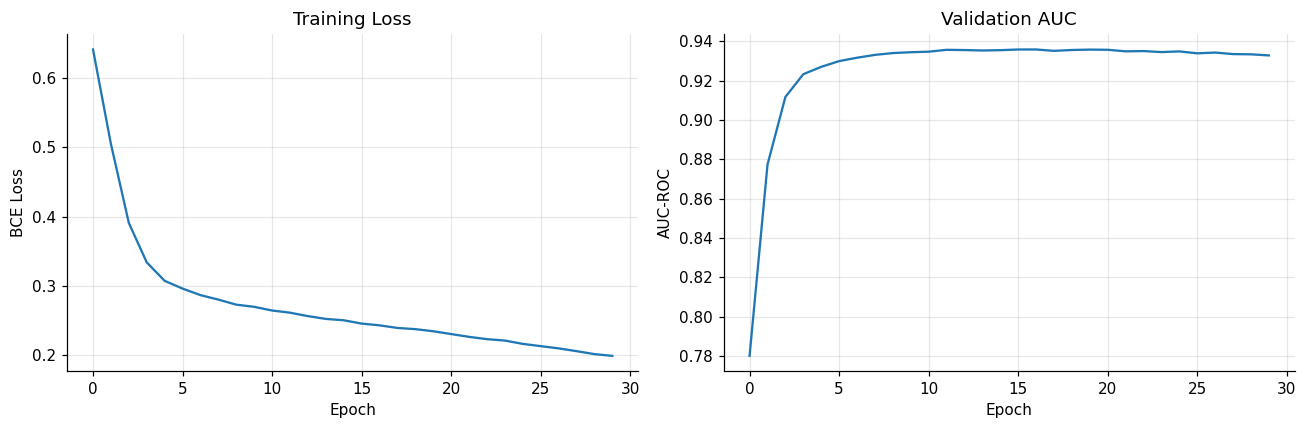

In [14]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(history['train_loss'])
ax1.set_title('Training Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('BCE Loss')

ax2.plot(history['val_auc'])
ax2.set_title('Validation AUC')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('AUC-ROC')

plt.tight_layout()
plt.show()

In [18]:
sample_learner_pos = test_idx[0]
uid = learner_ids[sample_learner_pos]

learner_df = df_bkt[df_bkt['user_id'] == uid].sort_values('order_id')

print(f"Learner {uid} - {len(learner_df)} total interactions")
print(learner_df[['order_id', 'skill_name', 'correct']].tail(10))

Learner 100459 - 250 total interactions
        order_id skill_name  correct
280668       241         99        0
280669       242        104        1
280670       243        137        1
280671       244         74        1
280672       245        144        1
280673       246         76        1
280674       247        120        0
280675       248        109        1
280676       249         86        1
280677       250         76        0


In [19]:
model.eval()   # turn off dropout for inference

# Grab from your pre-built arrays
skills_seq   = torch.tensor(skills_arr[sample_learner_pos],   dtype=torch.long).unsqueeze(0).to(device)   # (1, T)
corrects_seq = torch.tensor(corrects_arr[sample_learner_pos], dtype=torch.float).unsqueeze(0).to(device)  # (1, T)
mask_seq     = masks_arr[sample_learner_pos]   # (T,) — tells us where real data ends

# Find the last real timestep
last_real_step = int(mask_seq.sum()) - 1
print(f"Sequence length: {last_real_step + 1} real interactions")

Sequence length: 200 real interactions


In [20]:
with torch.no_grad():   # no gradients needed for inference
    # feed steps 0..last_real_step-1, predict at last_real_step
    pred = model(
        skills_seq[:, :last_real_step],
        corrects_seq[:, :last_real_step]
    )   # shape: (1, last_real_step, M)

# Predictions at the final step = what the model thinks about the NEXT interaction
next_step_probs = pred[0, -1, :].cpu().numpy()   # shape: (M,)
print(f"Predicted P(correct) for every skill at next step — shape: {next_step_probs.shape}")

Predicted P(correct) for every skill at next step — shape: (188,)


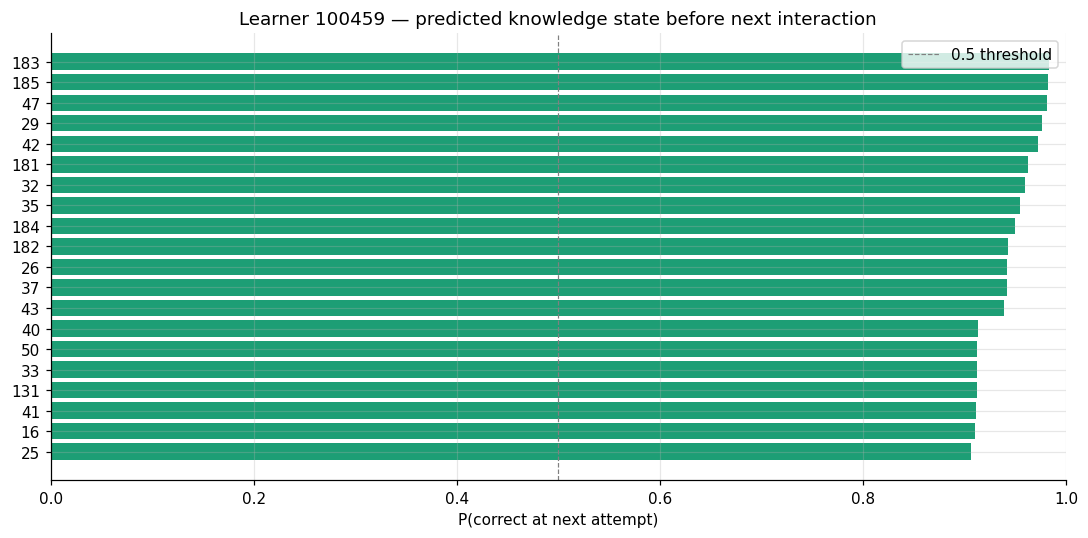

In [21]:
import matplotlib.pyplot as plt
import numpy as np

# Sort skills by predicted probability so the chart is readable
sorted_idx   = np.argsort(next_step_probs)[::-1]   # highest first
sorted_probs = next_step_probs[sorted_idx]
sorted_names = [idx2skill[i] for i in sorted_idx]

# Only plot top 20 if you have many skills
top_n = min(20, len(sorted_names))

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(sorted_names[:top_n][::-1], sorted_probs[:top_n][::-1],
               color=['#1D9E75' if p > 0.5 else '#EF9F27' for p in sorted_probs[:top_n][::-1]])

ax.axvline(x=0.5, color='grey', linestyle='--', linewidth=0.8, label='0.5 threshold')
ax.set_xlabel('P(correct at next attempt)')
ax.set_title(f'Learner {uid} — predicted knowledge state before next interaction')
ax.set_xlim(0, 1)
ax.legend()
plt.tight_layout()
plt.show()

In [22]:
# What did the learner actually do next?
actual_next = learner_df.iloc[last_real_step]   # the real next row
actual_skill = actual_next['skill_name']
actual_correct = int(actual_next['correct'])

predicted_prob = next_step_probs[skill2idx[actual_skill]]

print(f"\nActual next interaction:")
print(f"  Skill:    {actual_skill}")
print(f"  Correct:  {actual_correct}")
print(f"  Model predicted P(correct) = {predicted_prob:.3f}")
print(f"  → {'✓ Good prediction' if abs(predicted_prob - actual_correct) < 0.3 else '✗ Off'}")


Actual next interaction:
  Skill:    37
  Correct:  0
  Model predicted P(correct) = 0.942
  → ✗ Off


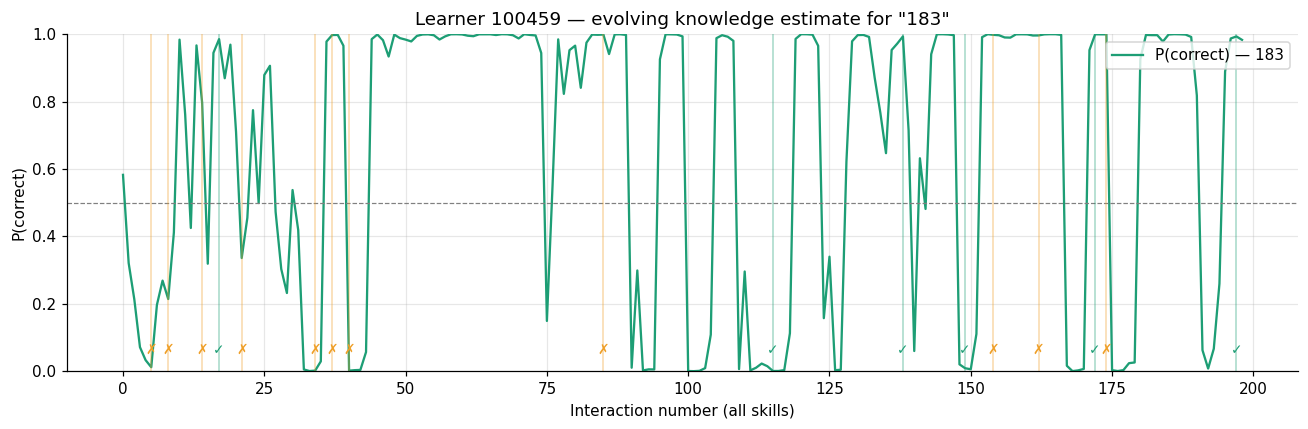

In [23]:
# Pick the skill the learner attempted most
top_skill_name = learner_df['skill_name'].value_counts().index[0]
top_skill_idx  = skill2idx[top_skill_name]

with torch.no_grad():
    # Run model over entire sequence, one step at a time
    all_preds = model(
        skills_seq[:, :last_real_step],
        corrects_seq[:, :last_real_step]
    )   # (1, last_real_step, M)

probs_over_time = all_preds[0, :, top_skill_idx].cpu().numpy()   # (T,)

# Get the actual attempts on this skill only
skill_attempts = learner_df[learner_df['skill_name'] == top_skill_name].copy()
skill_attempts['seq_position'] = [
    learner_df.index.get_loc(i) for i in skill_attempts.index
]

fig, ax = plt.subplots(figsize=(12, 4))

ax.plot(probs_over_time, color='#1D9E75', linewidth=1.5, label=f'P(correct) — {top_skill_name}')
ax.axhline(y=0.5, color='grey', linestyle='--', linewidth=0.8)

# Mark actual attempts on this skill
for _, row in skill_attempts.iterrows():
    pos = row['seq_position']
    if pos < len(probs_over_time):
        color = '#1D9E75' if row['correct'] == 1 else '#EF9F27'
        marker = '✓' if row['correct'] == 1 else '✗'
        ax.axvline(x=pos, color=color, alpha=0.4, linewidth=1)
        ax.text(pos, 0.05, marker, ha='center', fontsize=9, color=color)

ax.set_xlabel('Interaction number (all skills)')
ax.set_ylabel('P(correct)')
ax.set_title(f'Learner {uid} — evolving knowledge estimate for "{top_skill_name}"')
ax.set_ylim(0, 1)
ax.legend()
plt.tight_layout()
plt.show()